# Boosting Technique Assignment

## Theory Question

### Q.1. What is Boosting in Machine Learning? Explain how it improves weak learners.

--> Boosting is an ensemble learning technique in machine learning that combines multiple weak learners to form a strong predictive model. A weak learner is a model that performs only slightly better than random guessing. Boosting works by training models sequentially, where each new model focuses more on the data points that were incorrectly predicted by the previous models.

--> By assigning higher weights to misclassified observations, boosting forces subsequent learners to concentrate on harder cases. Over multiple iterations, the ensemble gradually reduces bias and improves overall accuracy. The final prediction is obtained by combining the predictions of all weak learners, often using weighted voting or weighted averaging.

### Q.2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

--> AdaBoost focuses on misclassified samples using weights, while Gradient Boosting focuses on minimizing loss using gradients.

--> AdaBoost (Adaptive Boosting) trains weak learners sequentially and adjusts the weights of training samples. Misclassified samples are given higher weights so that the next learner focuses more on them. The model performance improves by re-weighting data points.

--> Gradient Boosting trains models sequentially by minimizing a loss function using gradient descent. Each new model learns to predict the residual errors (gradients) made by the previous model instead of re-weighting data points.

### Q.3. How does regularization help in XGBoost?

--> Regularization in XGBoost helps prevent overfitting by penalizing model complexity. XGBoost introduces both L1 (Lasso) and L2 (Ridge) regularization on leaf weights of decision trees.

--> L1 regularization (alpha) encourages sparsity by reducing unnecessary leaf weights.

--> L2 regularization (lambda) smooths leaf weights and prevents extreme values.

--> Parameters like maximum tree depth, minimum child weight, and subsampling further control model complexity. Together, these regularization techniques make XGBoost more robust and generalizable compared to traditional gradient boosting.

### Q.4. Why is CatBoost considered efficient for handling categorical data?

--> CatBoost is designed to handle categorical features efficiently without extensive preprocessing. It uses an internal technique called ordered target encoding, which converts categorical values into numerical representations while avoiding target leakage.

--> CatBoost also uses symmetric (oblivious) decision trees, which improve training speed and reduce overfitting. As a result, CatBoost eliminates the need for manual one-hot encoding and performs well even when datasets contain many categorical variables.

### Q.5. What are some real-world applications where boosting techniques are preferred over bagging methods?

-->Boosting techniques are preferred over bagging when reducing bias and improving predictive accuracy is critical. Boosting is especially effective in complex problems where weak learners need guidance to focus on difficult patterns. Real-world applications:

>Credit risk and loan default prediction

>Fraud detection systems

>Medical diagnosis and disease prediction

>Customer churn prediction

>Search engine ranking and recommendation systems

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Q.6.  Write a Python program to:
>● Train an AdaBoost Classifier on the Breast Cancer dataset

>● Print the model accuracy

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model's Accuracy:", accuracy)

Model's Accuracy: 0.9736842105263158


### Q.7. Write a Python program to:
>● Train a Gradient Boosting Regressor on the California Housing dataset

>● Evaluate performance using R-squared score


In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R-squared Score:", r2)

R-squared Score: 0.7756446042829697


### Q.8. Write a Python program to:
>● Train an XGBoost Classifier on the Breast Cancer dataset

>● Tune the learning rate using GridSearchCV

>● Print the best parameters and accuracy

In [16]:
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
params = {'learning_rate': [0.01, 0.1, 0.2]}

grid = GridSearchCV(model, params, cv=3)
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


### Q.9. Write a Python program to:
>● Train a CatBoost Classifier

>● Plot the confusion matrix using seaborn

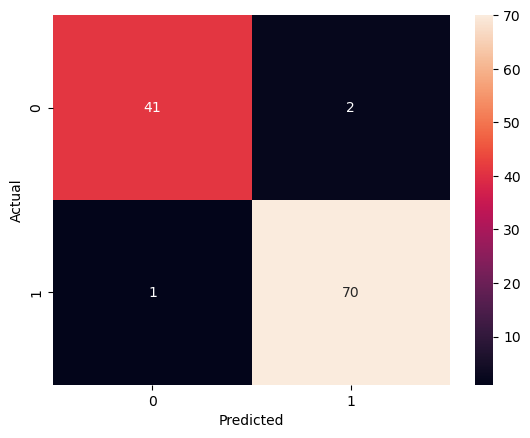

In [18]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Q.10. You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features.
>Describe your step-by-step data science pipeline using boosting techniques:

>>● Data preprocessing & handling missing/categorical values

>>● Choice between AdaBoost, XGBoost, or CatBoost

>>● Hyperparameter tuning strategy

>>● Evaluation metrics you'd choose and why

>>● How the business would benefit from your model

1. Problem Understanding

The objective is to predict whether a customer will default on a loan. Since loan defaults are rare events, the dataset is highly imbalanced. Incorrectly predicting a defaulter as a safe customer has serious financial consequences, so the focus is on recall and risk reduction rather than just accuracy.

2. Data Preprocessing

Handling Missing Values:

>Numerical features: Impute using median values to reduce the effect of outliers.

>Categorical features: Impute using mode or a special category such as "Unknown".

Handling Categorical Variables:

Instead of manual encoding, CatBoost is chosen because it natively handles categorical variables using ordered target encoding.

Handling Imbalanced Data:

Use class weights to penalize misclassification of the minority (default) class.

Alternatively, evaluation metrics are chosen that are robust to imbalance.

3. Model Selection (Boosting Choice)

Among AdaBoost, XGBoost, and CatBoost:

AdaBoost struggles with noisy and complex datasets.

XGBoost is powerful but requires extensive preprocessing for categorical features.

CatBoost is the best choice because it:

Handles categorical features automatically

Deals well with missing values

Reduces overfitting using ordered boosting

Performs well on imbalanced financial datasets

Therefore, CatBoost Classifier is selected.

4. Hyperparameter Tuning Strategy

Hyperparameters to tune:

learning_rate – controls step size

depth – controls tree complexity

iterations – number of trees

Tuning approach:

Use GridSearchCV or RandomizedSearchCV with cross‑validation

Optimize based on ROC‑AUC score instead of accuracy

5. Business Impact

The deployed boosting model provides the following benefits:

Reduces loan default rates by accurately identifying risky customers

Improves profitability by lowering non‑performing assets

Enables faster, automated credit decisions

Supports risk‑based pricing and better customer segmentation

# Conclusion

Using CatBoost with proper preprocessing, hyperparameter tuning, and imbalance‑aware evaluation metrics results in a robust and business‑effective loan default prediction system. Boosting techniques allow the FinTech company to make accurate, data‑driven lending decisions while minimizing risk.